In [1]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from qsmp import tree
from spectrum import MultiTapering

In [55]:
plt.rcParams.update({
    "text.usetex": True,    
    "font.size": 12,
    "font.family": "serif",
})
img_dir = Path('../results/img/')

In [3]:
data_file = Path('../data/study019-preictal/qsmp_T_splice.npz')
with np.load(data_file, allow_pickle=True) as data:
    T = data['T']
    splice = data['splice']

In [4]:
win_len = 768
tot_win = np.sum(np.diff(np.r_[0, splice, T.size])//win_len)
X = np.zeros((tot_win, win_len))
start_arr = np.r_[0, splice]
end_arr = np.r_[splice, T.size]
start_x = 0
for start, end in zip(start_arr, end_arr):
    segment = T[start:end]
    n_win = segment.size//win_len
    i_win = np.arange(0, n_win*win_len, win_len)
    i_win = i_win[:, None] + np.arange(win_len)[None, :]
    X[start_x:start_x+n_win] = segment[i_win]
    start_x = start_x + n_win

In [5]:
X.shape

(7518, 768)

In [6]:
QSMP_file = Path('../results/study019-preictal/qsmp_m-512_sigma-0.9_1.0_2.0_4.0_6.0_8.0_12.0_16.0_rect-50_minfilt-256.npz')
with np.load(QSMP_file) as data:
    density = data['density'].T
    NNdist = data['profile'].T
    NNindex = data['indices'].T

In [7]:
def find_tau(k, subseq_len, density, NNindex, NNdist):    
    max_tau = np.max(NNdist)
    min_tau = np.min(NNdist[NNdist>0])
    step = (max_tau - min_tau)/2
    tau = min_tau + step
    prev_left = min_tau
    prev_right = max_tau
    while True:    
        NNd, NNi, modes, cluster_size = tree.tree2clusters(
            subseq_len, density, NNindex, NNdist, tau)
        n_modes = modes.size        
        if n_modes == k:
            break
        elif n_modes > k:
            step = (prev_right - tau)/2
            prev_left = tau
            tau = tau + step            
        else:
            step = (tau - prev_left)/2
            prev_right = tau
            tau = tau - step
    return tau

In [74]:
# subseq_len, k = 512, 128
subseq_len, k = 512, 128
i_sigma = 1
tau = find_tau(k, subseq_len, density[i_sigma], NNindex[i_sigma], NNdist[i_sigma])
print(tau)

6.559116606083428


128


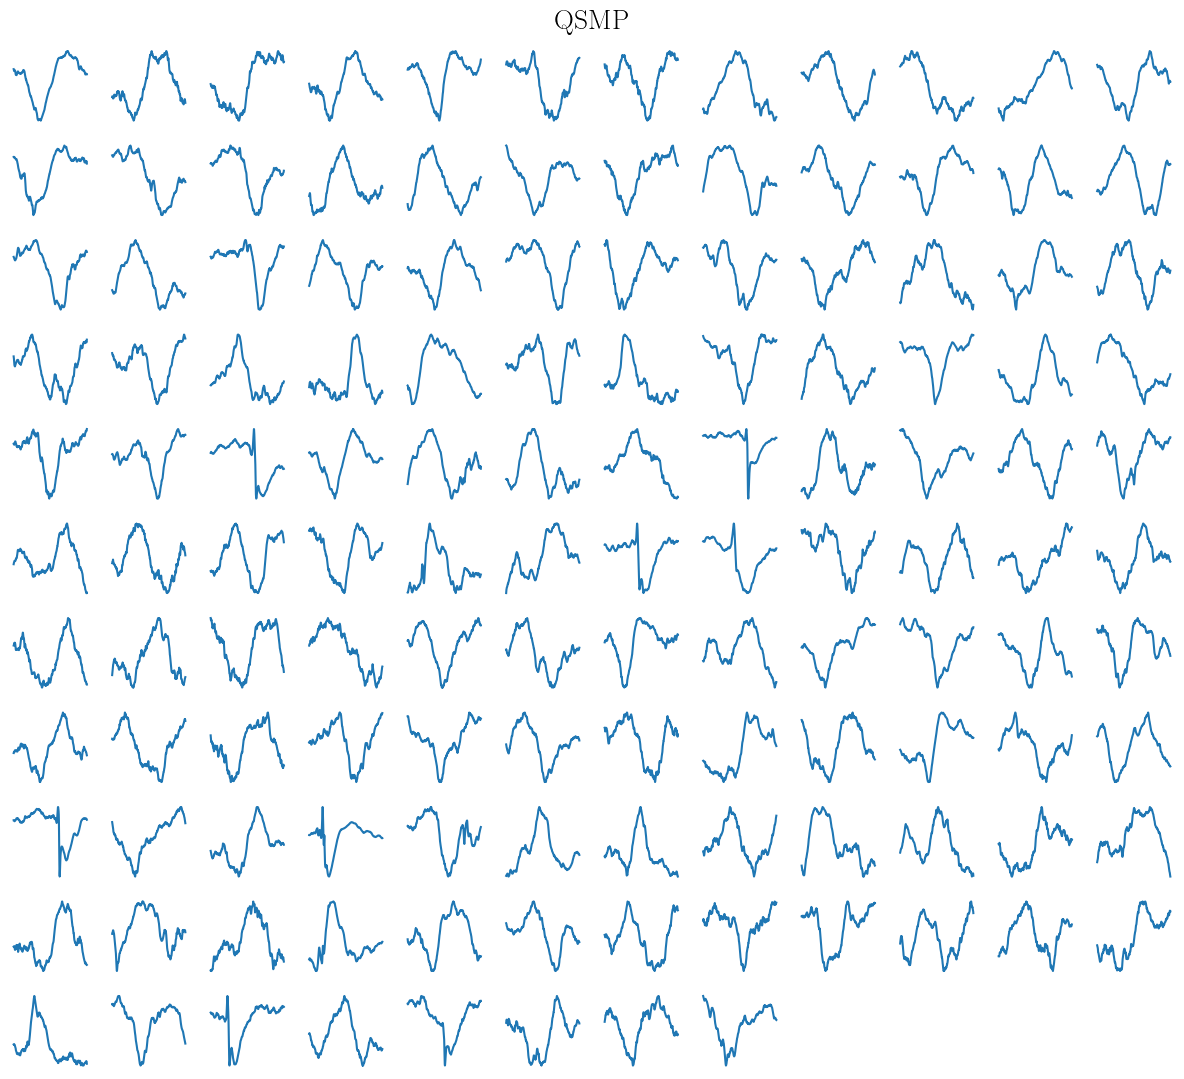

In [105]:
tau = 6.559
NNd, NNi, modes_idx, cluster_size = tree.tree2clusters(
    subseq_len, density[i_sigma], NNindex[i_sigma],
    NNdist[i_sigma], tau
)
# isort = np.argsort(-cluster_size)
# cluster_size = cluster_size[isort]
print(modes_idx.size)

n_rows = int(np.sqrt(k))
n_cols = np.ceil(k/n_rows).astype(int)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols, n_rows))
ax = ax.flatten()
for i in range(len(ax)):
    if i < k:
        wave = T[modes_idx[i]:modes_idx[i]+subseq_len]
        ax[i].plot(wave)
    ax[i].axis('off')

fig.suptitle('QSMP', fontsize=20)
plt.tight_layout()
fpath = img_dir.joinpath('study019-preictal_waves_QSMP.pdf')
# plt.savefig(fpath, bbox_inches='tight', pad_inches=0)

In [ ]:
sikmeans_file = Path('../results/study019-preictal/sikmeans_k-128_P-512_wlen-768.npz')
with np.load(sikmeans_file) as data:
    centroids = data['centroids']
    labels = data['labels']
    shifts = data['shifts']
    distances = data['distances']

unique_label, label_count = np.unique(labels, return_counts=True)
isort = np.argsort(-label_count)
centroids = centroids[isort]
unique_label = unique_label[isort]
label_count = label_count[isort]

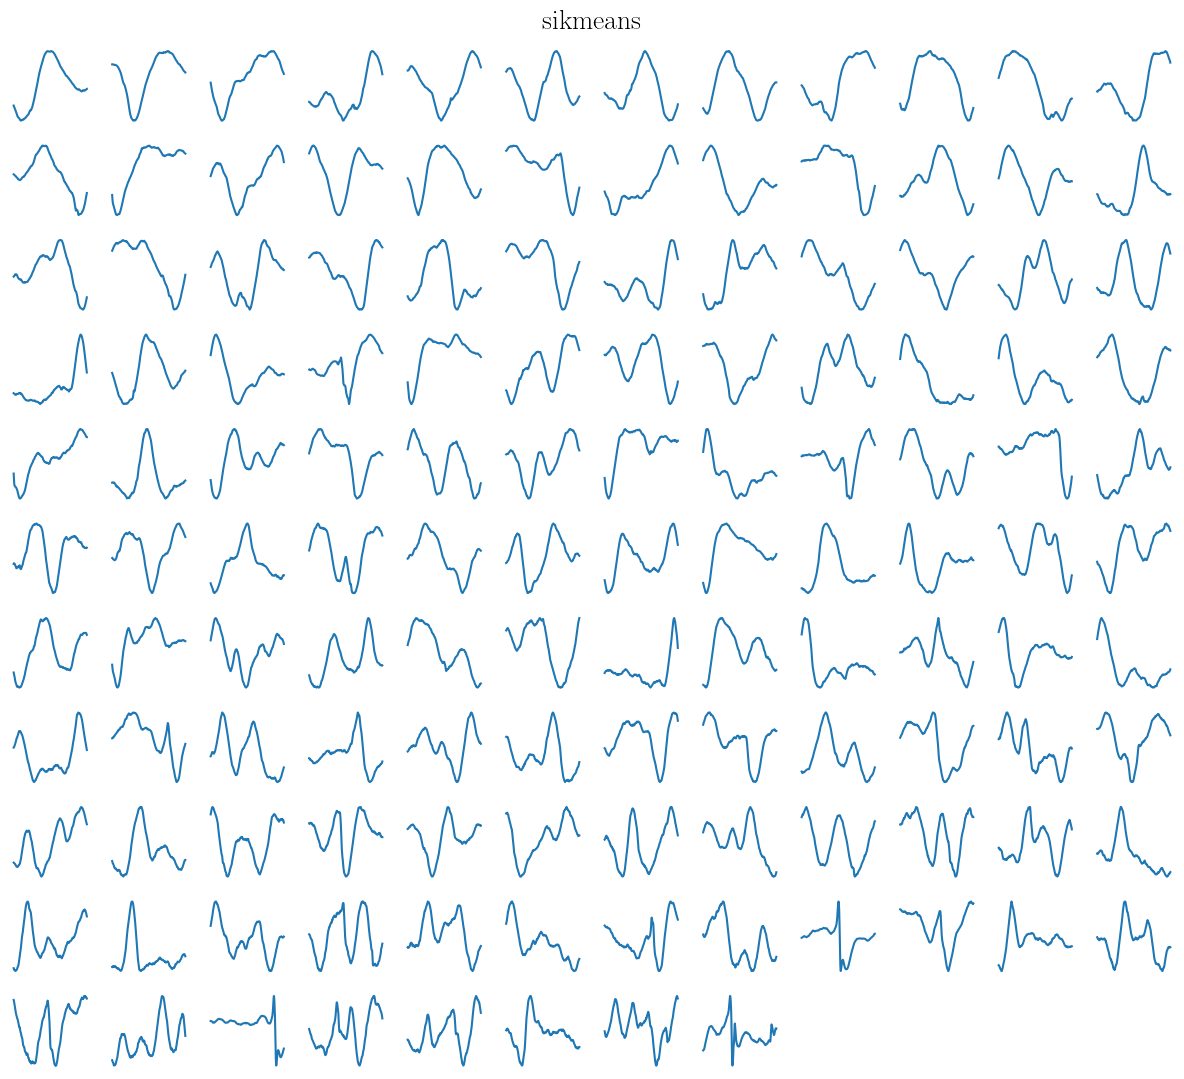

In [77]:
fig, ax = plt.subplots(11, 12, figsize=(12,11))
ax = ax.flatten()
for i in range(len(ax)):
    if i < k:        
        ax[i].plot(centroids[i])
    ax[i].axis('off')

fig.suptitle('sikmeans', fontsize=20)
plt.tight_layout()
fpath = img_dir.joinpath('study019-preictal_waves_sikmeans.pdf')
# plt.savefig(fpath, bbox_inches='tight', pad_inches=0)

In [89]:
max_modes = 128
n_neighbors = 20
i_sigma, sigmas = 1, 1.0
# fig, ax = plt.subplots(2, 2, figsize=(4, 4))

sample, idx = tree.get_neighbors(
    T, subseq_len, density[i_sigma], NNi,
    NNd, modes_idx, max_modes, n_neighbors
)

In [79]:
k

128

In [80]:
sikmeans_clusters = [None] * k
for i in range(k):
    this_cluster = (labels == unique_label[i]).nonzero()[0]
    cluster = X[this_cluster]
    cluster_dists = distances[this_cluster]
    cluster_shifts = shifts[this_cluster]
    isort = np.argsort(cluster_dists)
    cluster = cluster[isort][:n_neighbors+1]
    cluster_shifts = cluster_shifts[isort]
    sikmeans_clusters[i] = np.zeros((len(cluster), subseq_len))
    for j, wave in enumerate(cluster):
        sikmeans_clusters[i][j] = wave[cluster_shifts[j]:cluster_shifts[j]+subseq_len]

3


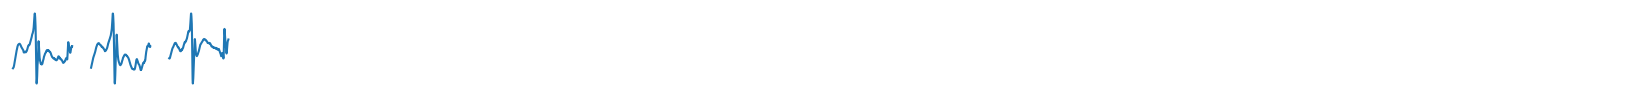

In [102]:
i_cluster = 127
# i_cluster = 122
# i_cluster = 116
print(label_count[i_cluster])
fig, ax = plt.subplots(1,n_neighbors+1, figsize=(n_neighbors+1,1))
ax[0].plot(centroids[i_cluster])
ax[0].axis('off')
for i in range(1, n_neighbors+1):
    if i < label_count[i_cluster]:
        ax[i].plot(sikmeans_clusters[i_cluster][i-1])
    ax[i].axis('off')

648


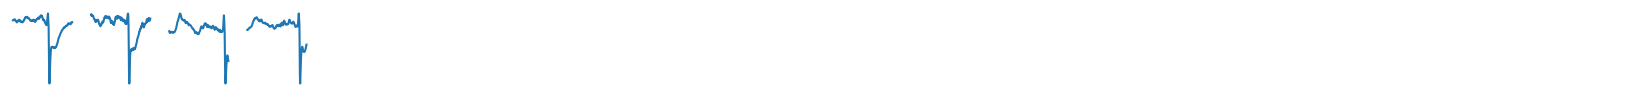

In [100]:
# i_cluster = 50
i_cluster = 55
print(cluster_size[i_cluster])
fig, ax = plt.subplots(1, n_neighbors+1, figsize=(n_neighbors+1,1))
for i in range(n_neighbors+1):
    if i < len(sample[i_cluster]):
        ax[i].plot(sample[i_cluster][i])
    ax[i].axis('off')

In [92]:
sample[i_cluster].shape

(5, 512)

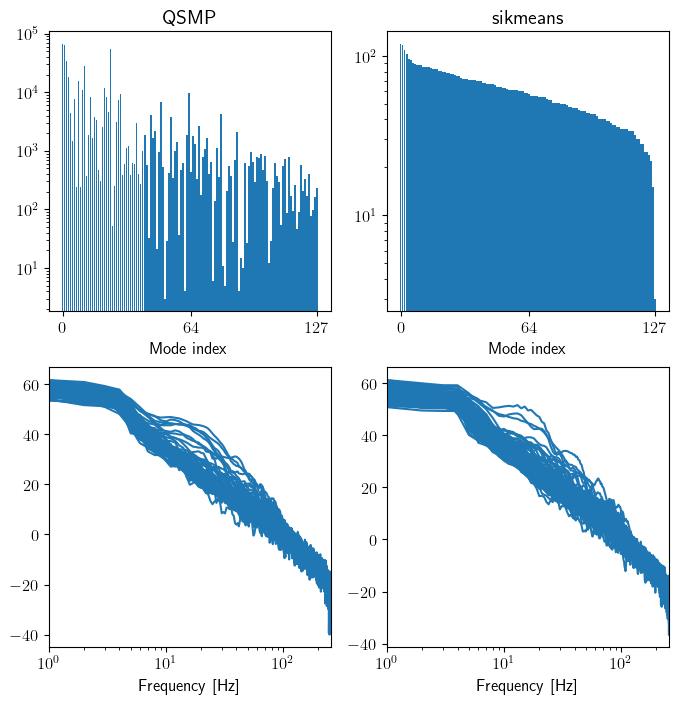

In [17]:
f = np.arange(1,257)  # start from 1 to ease viz of logx
colors = list(mcolors.TABLEAU_COLORS.values())

rows = (
    (cluster_size, label_count),
    (sample, sikmeans_clusters)
)
titles = ['QSMP', 'sikmeans']

fig, ax = plt.subplots(2, 2, figsize=(8, 8))

for i, row in enumerate(rows):
    for j, col in enumerate(row):
        if i == 0:
            ax[i,j].bar(np.arange(k), col)
            ax[i,j].set_xticks([0, 64, 127])
            ax[i,j].set_yscale('log')
            ax[i,j].set_title(titles[j])
            ax[i,j].set_xlabel('Mode index')
        else:
            for mode_ind, cluster in enumerate(col):
                tmp_PSD = np.zeros((len(cluster), subseq_len//2+1))
                for i_node in range(len(cluster)): #range(1):#
                    XX = MultiTapering(cluster[i_node], NW=3, sampling=512)
                    tmp_PSD[i_node] = XX.psd
                mean_PSD = np.mean(tmp_PSD, axis=0)[1:]                
                ax[i,j].plot(f, 10*np.log10(mean_PSD), color=colors[0], label=f'{mode_ind}')

            ax[i,j].set_xlim([f[0], f[-1]])
            ax[i,j].set_xscale('log')
            ax[i,j].set_xlabel('Frequency [Hz]')
# if i == 0:
#     ax[i,j].set_title(f'{max_dist:.3f}', fontsize=12)
# if j == 0:
#     ax[i,j].set_ylabel(f'{sigma:.1f}', fontsize=12)
            
# st = fig.suptitle('$\\tau$')
# xx, yy = st.get_position()
# st.set_position((xx, yy-0.02))
# sx = fig.supxlabel('Mode index')
# xx, yy = sx.get_position()
# sx.set_position((xx, yy+0.03))
# sy = fig.supylabel('$\sigma$')
# xx, yy = sy.get_position()
# sy.set_position((xx+0.02, yy))
# plt.tight_layout()
# fpath = img_dir.joinpath('morlet_hist_sigma_tau.pdf')
# plt.savefig(fpath, bbox_inches='tight', pad_inches=0)

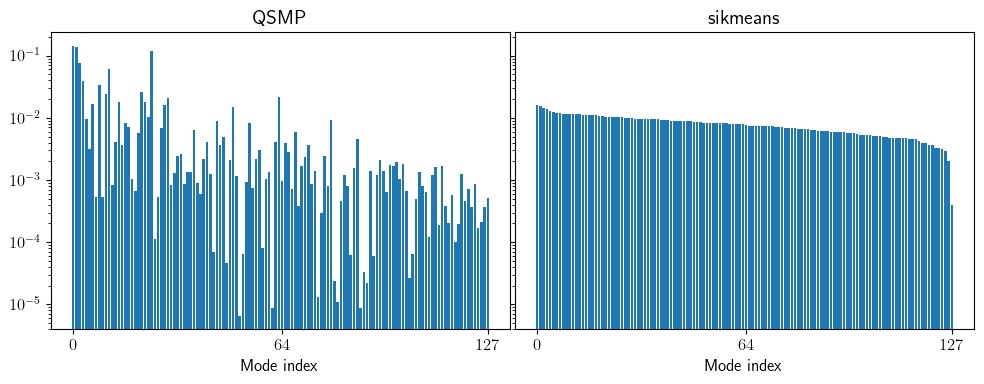

In [36]:
# %matplotlib ipympl
%matplotlib inline
row = (cluster_size, label_count)
titles = ['QSMP', 'sikmeans']

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for i, col in enumerate(row):
    ax[i].bar(np.arange(k), col/col.sum())
    ax[i].set_xticks([0, 64, 127])
    ax[i].set_yscale('log')
    ax[i].set_title(titles[i])
    ax[i].set_xlabel('Mode index')
plt.tight_layout(w_pad=0)
fpath = img_dir.joinpath('study019-preictal_hist_QSMP_vs_sikmeans.pdf')
plt.savefig(fpath, bbox_inches='tight', pad_inches=0)

In [42]:
cluster_size[:10]

array([66371, 63983, 34754, 17998,  4355,  1446,  7695,   243, 15637,
         241])

In [43]:
label_count[:10]

array([119, 118, 109, 103,  96,  94,  90,  89,  88,  88])